<a href="https://colab.research.google.com/github/farrelrassya/PracticalLinearAlgebra/blob/main/07.Chapter7%3AMatrix_apps.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7: Matrix Applications
## *Practical Linear Algebra for Data Science* — Mike X Cohen

Chapters 5 and 6 built the theoretical machinery of matrices. This chapter puts that machinery to work on three applications that are central to data science and computer graphics:

$$
\underbrace{\mathbf{X}^T\mathbf{X}}_{\text{Covariance matrices}}
\qquad
\underbrace{\mathbf{T}\mathbf{p}}_{\text{Geometric transforms}}
\qquad
\underbrace{\sum(\mathbf{K} \odot \mathbf{S})}_{\text{Image filtering}}
$$

Each application builds on Chapter 4 (vector applications) by extending to matrices what we previously did with vectors. The recurring insight: matrix operations are *organised collections* of the same dot products and norms we mastered earlier.

**What we will cover:**

1. **Covariance and correlation matrices** -- $\mathbf{C} = \frac{1}{n-1}\tilde{\mathbf{X}}^T\tilde{\mathbf{X}}$ as a matrix of all pairwise dot products
2. **Geometric transformations** -- rotation matrices, animations, and the eigenvector preview
3. **Image feature detection** -- 2D convolution with Gaussian and edge-detection kernels

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12
})

np.random.seed(42)
print('NumPy version:', np.__version__)
print('Setup complete.')

NumPy version: 2.0.2
Setup complete.


Environment ready.

## 1. Multivariate Data Covariance Matrices

### 1.1 From Bivariate to Multivariate

In Chapter 4, we computed the Pearson correlation between *two* variables using the dot product of mean-centred vectors normalised by their norms. With $p$ variables, we need *all pairwise* correlations -- a $p \times p$ matrix. Rather than looping over pairs, matrix multiplication computes everything at once.

**Covariance** is the unnormalised version of correlation -- the dot product of mean-centred variables, divided by $n - 1$:

$$
c_{a,b} = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})
= \frac{\tilde{\mathbf{x}}^T \tilde{\mathbf{y}}}{n - 1}
$$

where $\tilde{\mathbf{x}} = \mathbf{x} - \bar{x}$ is the mean-centred variable.

### 1.2 The Matrix Formula

Pack all $p$ variables as columns of an $n \times p$ matrix $\mathbf{X}$. Mean-centre each column to get $\tilde{\mathbf{X}}$. Then:

$$
\mathbf{C} = \frac{1}{n-1} \tilde{\mathbf{X}}^T \tilde{\mathbf{X}}
$$

This works because $\tilde{\mathbf{X}}^T \tilde{\mathbf{X}}$ computes all pairwise dot products between columns: element $(i, j)$ is $\tilde{\mathbf{x}}_i^T \tilde{\mathbf{x}}_j$, which is the covariance numerator. The result is always **symmetric** ($c_{a,b} = c_{b,a}$) and **square** ($p \times p$), because $\mathbf{A}^T\mathbf{A}$ is always square symmetric (Chapter 5).

In [2]:
# Generate a multivariate dataset with known structure
np.random.seed(42)
n = 500  # observations
p = 6    # features

# Latent factors
z1 = np.random.randn(n)
z2 = np.random.randn(n)

# Features with controlled correlations
X = np.column_stack([
    z1 + 0.3*np.random.randn(n),        # x0: loads on z1
    0.8*z1 + 0.6*np.random.randn(n),    # x1: loads on z1
    -0.5*z1 + 0.9*np.random.randn(n),   # x2: negatively loads on z1
    z2 + 0.3*np.random.randn(n),        # x3: loads on z2
    0.7*z2 + 0.7*np.random.randn(n),    # x4: loads on z2
    np.random.randn(n),                   # x5: independent noise
])
feature_names = ['$x_0$', '$x_1$', '$x_2$', '$x_3$', '$x_4$', '$x_5$']

print(f'Data matrix X: {X.shape} ({n} observations x {p} features)')

Data matrix X: (500, 6) (500 observations x 6 features)


We created a $500 \times 6$ data matrix where features $x_0, x_1, x_2$ share a common latent factor $z_1$ (with $x_2$ loading negatively), features $x_3, x_4$ share $z_2$, and $x_5$ is pure noise. The covariance matrix should reveal this block structure.

### 1.3 Computing the Covariance Matrix from First Principles

In [3]:
# Step 1: Mean-centre each column
col_means = np.mean(X, axis=0)
X_tilde = X - col_means  # broadcasting: (500, 6) - (6,)

# Step 2: Covariance via matrix multiplication
C_manual = (X_tilde.T @ X_tilde) / (n - 1)

# Compare with NumPy
C_numpy = np.cov(X, rowvar=False)

print(f'Covariance matrix C ({C_manual.shape[0]}x{C_manual.shape[1]}):')
print(np.round(C_manual, 3))
print(f'\nMatch np.cov? {np.allclose(C_manual, C_numpy)}')
print(f'Symmetric? {np.allclose(C_manual, C_manual.T)}')
print(f'\nDiagonal (variances): {np.round(np.diag(C_manual), 3)}')

Covariance matrix C (6x6):
[[ 1.02   0.79  -0.491 -0.04  -0.032 -0.029]
 [ 0.79   1.024 -0.454 -0.059 -0.044 -0.023]
 [-0.491 -0.454  0.994  0.048  0.056  0.05 ]
 [-0.04  -0.059  0.048  1.078  0.677 -0.05 ]
 [-0.032 -0.044  0.056  0.677  1.011 -0.078]
 [-0.029 -0.023  0.05  -0.05  -0.078  1.034]]

Match np.cov? True
Symmetric? True

Diagonal (variances): [1.02  1.024 0.994 1.078 1.011 1.034]


The covariance matrix is $6 \times 6$, symmetric, and computed as $\mathbf{C} = \frac{1}{499}\tilde{\mathbf{X}}^T\tilde{\mathbf{X}}$. It matches `np.cov` to machine precision.

The **diagonal** contains the **variance** of each feature -- the covariance of a variable with itself. Off-diagonal elements are the pairwise covariances.

**Why $n - 1$?** This is Bessel's correction. Dividing by $n - 1$ instead of $n$ gives an unbiased estimator of the population covariance when working with a sample.

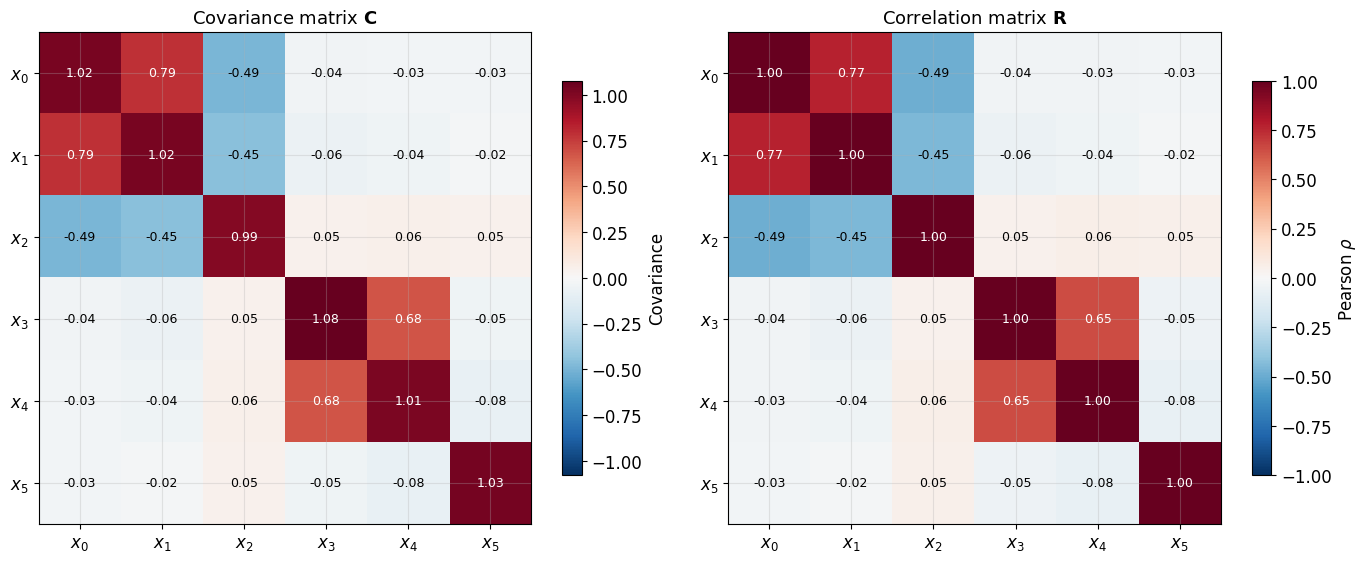

Correlation matrix matches np.corrcoef? True


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Covariance matrix
ax = axes[0]
vmax = np.max(np.abs(C_manual))
im = ax.imshow(C_manual, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax, shrink=0.8, label='Covariance')
ax.set_xticks(range(p)); ax.set_yticks(range(p))
ax.set_xticklabels(feature_names); ax.set_yticklabels(feature_names)
for i in range(p):
    for j in range(p):
        color = 'white' if abs(C_manual[i,j]) > vmax*0.5 else 'black'
        ax.text(j, i, f'{C_manual[i,j]:.2f}', ha='center', va='center',
                fontsize=9, color=color)
ax.set_title('Covariance matrix $\mathbf{C}$', fontsize=13)

# Correlation matrix
# Convert covariance to correlation: R_ij = C_ij / (sigma_i * sigma_j)
stds = np.sqrt(np.diag(C_manual))
R_manual = C_manual / np.outer(stds, stds)
R_numpy = np.corrcoef(X, rowvar=False)

ax = axes[1]
im = ax.imshow(R_manual, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson $\\rho$')
ax.set_xticks(range(p)); ax.set_yticks(range(p))
ax.set_xticklabels(feature_names); ax.set_yticklabels(feature_names)
for i in range(p):
    for j in range(p):
        color = 'white' if abs(R_manual[i,j]) > 0.5 else 'black'
        ax.text(j, i, f'{R_manual[i,j]:.2f}', ha='center', va='center',
                fontsize=9, color=color)
ax.set_title('Correlation matrix $\mathbf{R}$', fontsize=13)

plt.tight_layout()
plt.savefig('fig_cov_corr.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Correlation matrix matches np.corrcoef? {np.allclose(R_manual, R_numpy)}')

The **block structure** is exactly what we designed:

- The upper-left $3 \times 3$ block ($x_0, x_1, x_2$) shows the $z_1$ factor: $x_0$ and $x_1$ are positively correlated, while $x_2$ is negatively correlated with both.
- The centre block ($x_3, x_4$) shows the $z_2$ factor.
- $x_5$ has near-zero covariance with all other features (independent noise).
- Cross-block entries (e.g., $x_0$ vs $x_3$) are near zero -- the two factors are independent.

**From covariance to correlation:** Dividing each element by the product of the feature standard deviations normalises to the $[-1, +1]$ scale:

$$
R_{ij} = \frac{C_{ij}}{\sigma_i \sigma_j}
$$

In matrix notation: $\mathbf{R} = \mathbf{D}^{-1}\mathbf{C}\mathbf{D}^{-1}$ where $\mathbf{D} = \text{diag}(\sigma_1, \ldots, \sigma_p)$. The correlation matrix always has $1$s on the diagonal.

**Production insight:** Covariance matrices appear everywhere: as the core of PCA (Chapter 15), in Gaussian mixture models, in portfolio risk analysis, and in Kalman filters. Understanding $\mathbf{X}^T\mathbf{X}$ is understanding half of applied statistics.

## 2. Geometric Transformations via Matrix-Vector Multiplication

### 2.1 Pure Rotation Matrices

A **pure rotation matrix** rotates a vector without changing its length. In 2D:

$$
\mathbf{T}(\theta) = \begin{bmatrix} \cos\theta & \sin\theta \\ -\sin\theta & \cos\theta \end{bmatrix}
$$

This matrix has two remarkable properties:

1. **Columns are orthogonal:** $\cos\theta \cdot \sin\theta + (-\sin\theta) \cdot \cos\theta = 0$
2. **Columns are unit vectors:** $\cos^2\theta + \sin^2\theta = 1$ (Pythagorean identity)

A matrix with orthogonal unit-norm columns is called an **orthogonal matrix**. Orthogonal matrices satisfy $\mathbf{T}^T\mathbf{T} = \mathbf{I}$, which means $\mathbf{T}^{-1} = \mathbf{T}^T$ (Chapter 8).

Rotation angle: theta = pi/5 = 36 degrees

T =
[[ 0.809   0.5878]
 [-0.5878  0.809 ]]

Verify orthogonality: T^T @ T =
[[1. 0.]
 [0. 1.]]
det(T) = 1.000000  (1 = rotation, -1 = reflection)


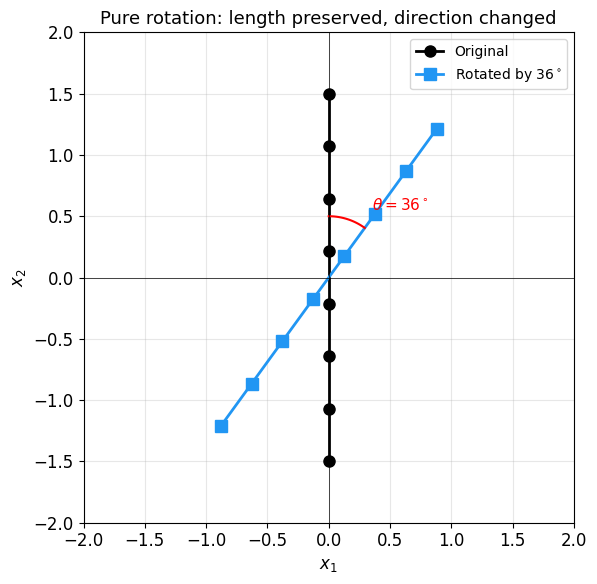

Figure saved.


In [5]:
# Demonstrate pure rotation
theta = np.pi / 5  # 36 degrees clockwise

T = np.array([[np.cos(theta),  np.sin(theta)],
              [-np.sin(theta), np.cos(theta)]])

print(f'Rotation angle: theta = pi/5 = {np.degrees(theta):.0f} degrees')
print(f'\nT =')
print(np.round(T, 4))
print(f'\nVerify orthogonality: T^T @ T =')
print(np.round(T.T @ T, 10))
print(f'det(T) = {np.linalg.det(T):.6f}  (1 = rotation, -1 = reflection)')

# Create vertical line of points and rotate
pts_y = np.linspace(-1.5, 1.5, 8)
pts = np.vstack([np.zeros_like(pts_y), pts_y])  # 2xN
pts_rot = T @ pts

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(pts[0], pts[1], 'ko-', ms=8, lw=2, label='Original')
ax.plot(pts_rot[0], pts_rot[1], 's-', color='#2196F3', ms=8, lw=2,
        label=f'Rotated by {np.degrees(theta):.0f}$^\\circ$')

# Draw arc showing rotation angle
arc_t = np.linspace(np.pi/2, np.pi/2 - theta, 30)
ax.plot(0.5*np.cos(arc_t), 0.5*np.sin(arc_t), 'r-', lw=1.5)
ax.text(0.35, 0.55, f'$\\theta = {np.degrees(theta):.0f}^\\circ$',
        fontsize=11, color='r')

ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Pure rotation: length preserved, direction changed', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_rotation.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

The rotation matrix $\mathbf{T}(\pi/5)$ satisfies $\mathbf{T}^T\mathbf{T} = \mathbf{I}$ (orthogonal) and $\det(\mathbf{T}) = 1$ (rotation, not reflection). The vertical line of points is rotated $36^\circ$ clockwise without any stretching -- every point maintains its distance from the origin.

**Changing rotation direction:** For *counterclockwise* rotation, negate $\theta$ (or equivalently, transpose the matrix, since $\mathbf{T}(-\theta) = \mathbf{T}(\theta)^T$).

### 2.2 General Transformations: The Wobbly Circle

A pure rotation matrix preserves lengths. General $2 \times 2$ transformation matrices can both **rotate** and **stretch**. The textbook's "Wobbly Circle" uses:

$$
\mathbf{T}(\varphi) = \begin{bmatrix} 1 & 1 - \varphi \\ 0 & 1 \end{bmatrix}
$$

The diagonal elements scale the axes (both $1$ here, so no scaling), while the off-diagonal $(1 - \varphi)$ shears the $x$-axis based on the $y$-coordinate. When $\varphi = 1$, $\mathbf{T} = \mathbf{I}$ (no transformation). As $\varphi$ moves away from $1$, the circle gets sheared.

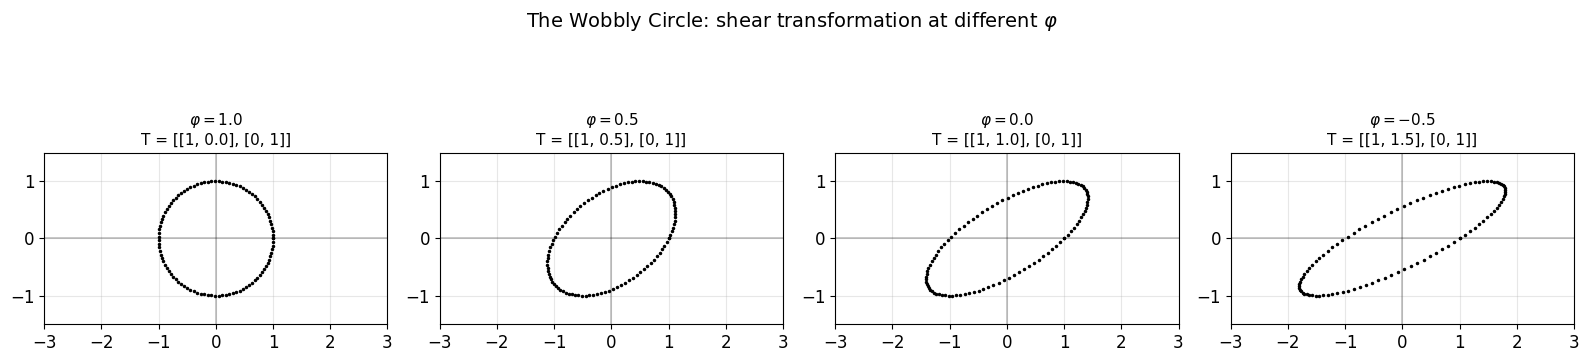

phi=  1.0: det(T) = 1.0, off-diag = 0.0
phi=  0.5: det(T) = 1.0, off-diag = 0.5
phi=  0.0: det(T) = 1.0, off-diag = 1.0
phi= -0.5: det(T) = 1.0, off-diag = 1.5


In [6]:
# The Wobbly Circle: static frames
theta = np.linspace(0, 2*np.pi, 100)
circle = np.vstack([np.cos(theta), np.sin(theta)])  # 2 x 100

phi_values = [1.0, 0.5, 0.0, -0.5]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, phi in zip(axes, phi_values):
    T = np.array([[1, 1 - phi], [0, 1]])
    transformed = T @ circle

    ax.plot(transformed[0], transformed[1], 'k.', ms=3)
    ax.set_title(f'$\\varphi = {phi}$\nT = [[1, {1-phi:.1f}], [0, 1]]',
                fontsize=11)
    ax.set_xlim(-3, 3); ax.set_ylim(-1.5, 1.5)
    ax.set_aspect('equal')
    ax.axhline(0, color='k', lw=0.3); ax.axvline(0, color='k', lw=0.3)

plt.suptitle('The Wobbly Circle: shear transformation at different $\\varphi$',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_wobbly.png', dpi=100, bbox_inches='tight')
plt.show()

# Verify: det(T) = 1 for all phi (area preserved!)
for phi in phi_values:
    T = np.array([[1, 1-phi], [0, 1]])
    print(f'phi={phi:5.1f}: det(T) = {np.linalg.det(T):.1f}, '
          f'off-diag = {1-phi:.1f}')

At $\varphi = 1$, $\mathbf{T} = \mathbf{I}$ and the circle is undistorted. As $\varphi$ decreases, the off-diagonal element $1 - \varphi$ introduces a **shear**: the upper half of the circle is pushed right and the lower half is pushed left. All frames have $\det(\mathbf{T}) = 1$, meaning the *area* is preserved even though the *shape* changes. This is a **shear transformation** -- one of the fundamental transformation types.

**Transformation matrix anatomy:**

| Element | Effect |
|---------|--------|
| Diagonal ($t_{11}, t_{22}$) | Scale $x$ and $y$ independently |
| Off-diagonal ($t_{12}$) | Shear $x$ based on $y$ |
| Off-diagonal ($t_{21}$) | Shear $y$ based on $x$ |

**Cross-chapter connection:** The determinant $\det(\mathbf{T}) = 0$ would mean the circle collapses to a line (Chapter 6). This is why singular matrices have $\det = 0$ -- they flatten at least one dimension.

### 2.3 The Determinant as an Area/Volume Scale Factor

The determinant tells us how a transformation scales area (2D) or volume (3D).

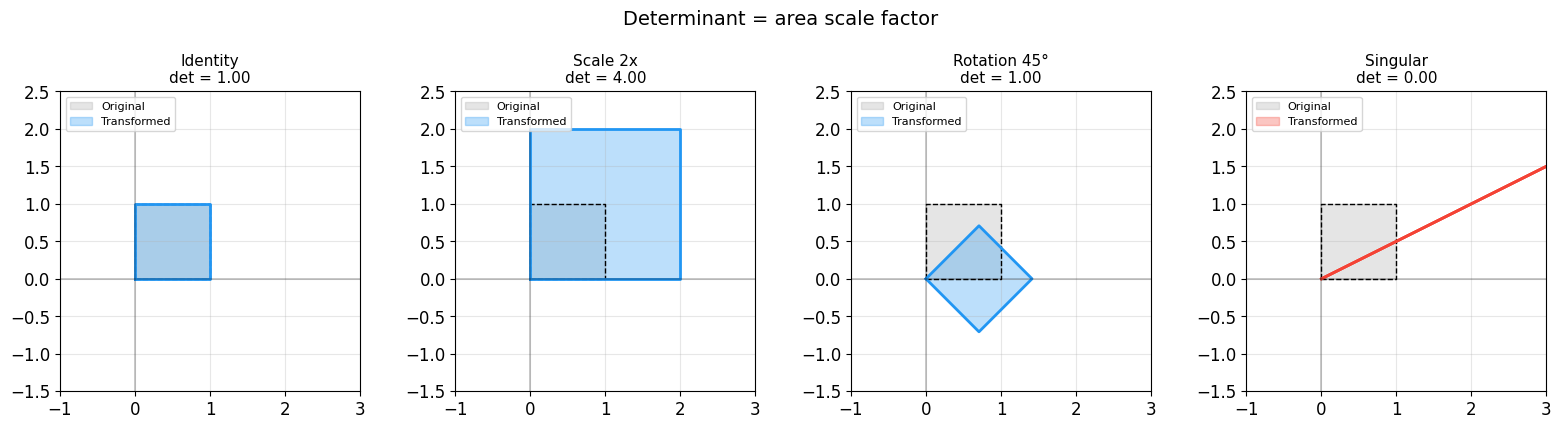

Figure saved.


In [7]:
# Demonstrate: det controls area scaling
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

transformations = [
    ('Identity', np.eye(2)),
    ('Scale 2x', 2*np.eye(2)),
    ('Rotation 45°', np.array([[np.cos(np.pi/4), np.sin(np.pi/4)],
                               [-np.sin(np.pi/4), np.cos(np.pi/4)]])),
    ('Singular', np.array([[1, 2], [0.5, 1]])),
]

# Unit square
square = np.array([[0, 1, 1, 0, 0],
                   [0, 0, 1, 1, 0]])

for ax, (name, T) in zip(axes, transformations):
    det = np.linalg.det(T)
    transformed = T @ square

    ax.fill(square[0], square[1], alpha=0.2, color='gray', label='Original')
    ax.plot(square[0], square[1], 'k--', lw=1)
    color = '#2196F3' if abs(det) > 0.01 else '#F44336'
    ax.fill(transformed[0], transformed[1], alpha=0.3, color=color,
            label='Transformed')
    ax.plot(transformed[0], transformed[1], '-', color=color, lw=2)
    ax.set_title(f'{name}\ndet = {det:.2f}', fontsize=11)
    ax.set_xlim(-1, 3); ax.set_ylim(-1.5, 2.5)
    ax.set_aspect('equal')
    ax.axhline(0, color='k', lw=0.3); ax.axvline(0, color='k', lw=0.3)
    ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Determinant = area scale factor', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_det_area.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

The four panels demonstrate the geometric meaning of the determinant:

- **Identity** ($\det = 1$): No change. Area preserved.
- **Scale 2x** ($\det = 4$): Each axis doubled, so area is $2 \times 2 = 4$ times larger.
- **Rotation 45°** ($\det = 1$): Shape rotated, area preserved (rotation is volume-preserving).
- **Singular** ($\det = 0$): The square collapses to a **line**. One dimension is completely flattened -- this is what $\det = 0$ means geometrically.

**Key insight from Chapter 6:** $\det = 0$ means rank-deficient. Geometrically: the transformation maps all of $\mathbb{R}^2$ onto a lower-dimensional subspace. This is why singular matrices cannot be inverted -- you cannot recover the original shape from a flattened line.

## 3. Image Feature Detection

### 3.1 From 1D to 2D Convolution

In Chapter 4, we filtered time series by sliding a 1D kernel and computing dot products. Image filtering extends this to **2D**: a 2D kernel slides across the image, and at each position we compute a Hadamard product and sum:

$$
\text{output}(r, c) = \sum_{i} \sum_{j} K_{i,j} \cdot S_{r+i,\, c+j}
= \text{sum}(\mathbf{K} \odot \mathbf{S}_{\text{patch}})
$$

This is the same element-wise-multiply-and-sum operation as a dot product, but applied to matrices (Hadamard product + sum). The kernel $\mathbf{K}$ determines what feature is detected.

### 3.2 Gaussian Smoothing Kernel

A **2D Gaussian** kernel acts as a smoother -- it replaces each pixel with a weighted average of its neighbours:

$$
G(x, y) = \exp\left(-\frac{x^2 + y^2}{\sigma}\right)
$$

The parameter $\sigma$ controls the width: larger $\sigma$ means more smoothing.

Gaussian kernel shape: (21, 21)
Sum of kernel elements: 1.000000 (normalised to 1)
Peak value: 0.0031


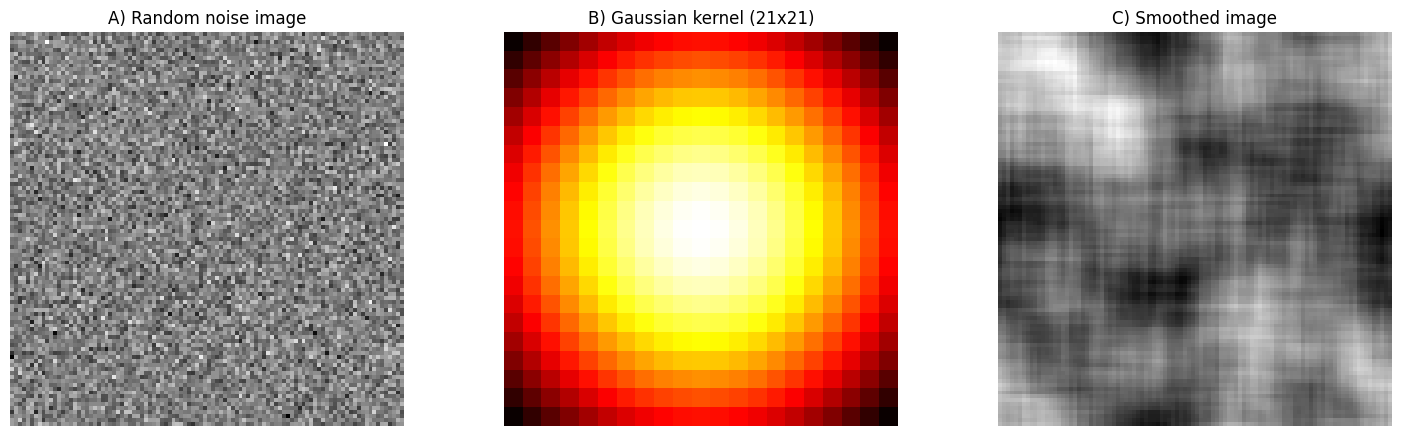

Figure saved.


In [8]:
# Create 2D Gaussian kernel
Y_grid, X_grid = np.meshgrid(np.linspace(-3, 3, 21), np.linspace(-3, 3, 21))
sigma = 20
kernel_gauss = np.exp(-(X_grid**2 + Y_grid**2) / sigma)
kernel_gauss = kernel_gauss / np.sum(kernel_gauss)  # normalise

print(f'Gaussian kernel shape: {kernel_gauss.shape}')
print(f'Sum of kernel elements: {np.sum(kernel_gauss):.6f} (normalised to 1)')
print(f'Peak value: {np.max(kernel_gauss):.4f}')

# Create a random image and smooth it
np.random.seed(42)
img_random = np.random.randn(100, 100)
img_smooth = convolve2d(img_random, kernel_gauss, mode='same', boundary='wrap')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
ax.imshow(img_random, cmap='gray')
ax.set_title('A) Random noise image', fontsize=12)
ax.axis('off')

ax = axes[1]
ax.imshow(kernel_gauss, cmap='hot')
ax.set_title(f'B) Gaussian kernel ({kernel_gauss.shape[0]}x{kernel_gauss.shape[1]})',
             fontsize=12)
ax.axis('off')

ax = axes[2]
ax.imshow(img_smooth, cmap='gray')
ax.set_title('C) Smoothed image', fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.savefig('fig_gauss_smooth.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

The Gaussian kernel is a $21 \times 21$ matrix with a bright centre that fades toward the edges. When convolved with the random noise image, the result is a blurred version: high-frequency pixel-to-pixel noise is averaged out, leaving smooth low-frequency patterns.

The kernel is **normalised** (sums to $1$) so that convolution computes a weighted average rather than a weighted sum. This preserves the original intensity scale.

**Connection to Chapter 4:** The 1D smoothing kernel $\mathbf{k} = \frac{1}{m}[1, 1, \ldots, 1]^T$ was a uniform average. The 2D Gaussian kernel is a *weighted* average where nearby pixels contribute more than distant ones -- a more sophisticated version of the same idea.

### 3.3 Edge Detection Kernels

Different kernels detect different features. **Edge detection** kernels highlight regions where pixel intensity changes abruptly.

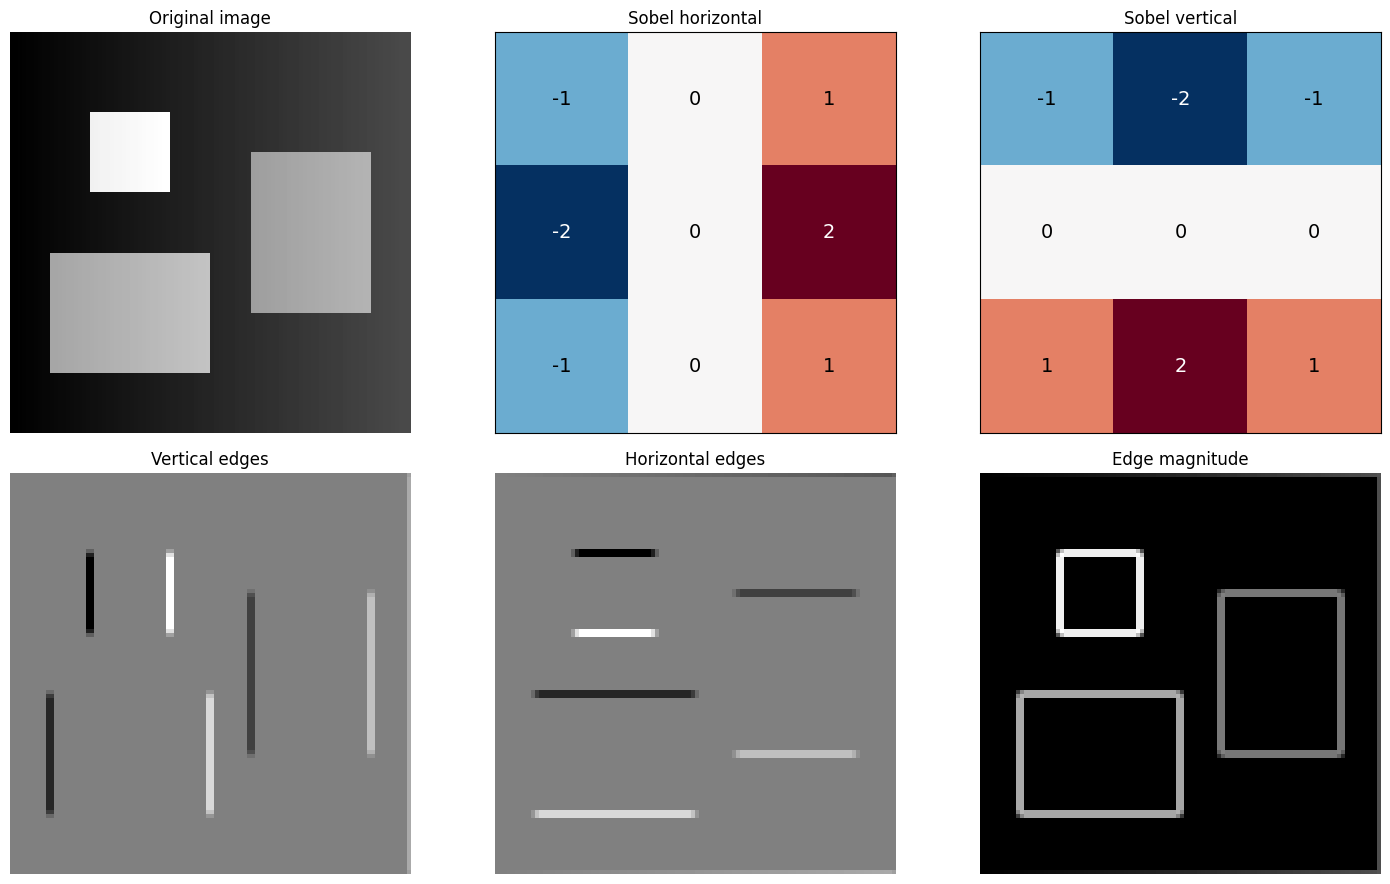

Sobel H kernel sum: 0 (sums to 0: no DC bias)
Sobel V kernel sum: 0 (sums to 0: no DC bias)


In [9]:
# Create an image with clear features
np.random.seed(42)
img_test = np.zeros((100, 100))

# Add shapes
img_test[20:40, 20:40] = 1.0        # bright square (upper-left)
img_test[55:85, 10:50] = 0.7        # dimmer rectangle (lower-left)
img_test[30:70, 60:90] = 0.5        # mid-brightness rectangle (right)
# Add a gradient
for i in range(100):
    img_test[:, i] += i / 300

# Edge detection kernels
# Sobel horizontal (detects vertical edges)
sobel_h = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

# Sobel vertical (detects horizontal edges)
sobel_v = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

# Apply edge detection
edges_h = convolve2d(img_test, sobel_h, mode='same', boundary='fill')
edges_v = convolve2d(img_test, sobel_v, mode='same', boundary='fill')
edges_mag = np.sqrt(edges_h**2 + edges_v**2)  # combined magnitude

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Top row: image and kernels
axes[0,0].imshow(img_test, cmap='gray')
axes[0,0].set_title('Original image', fontsize=12)
axes[0,0].axis('off')

for ax, K, name in zip([axes[0,1], axes[0,2]],
                        [sobel_h, sobel_v],
                        ['Sobel horizontal', 'Sobel vertical']):
    im = ax.imshow(K, cmap='RdBu_r', vmin=-2, vmax=2)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(K[i,j]), ha='center', va='center', fontsize=14,
                    color='k' if abs(K[i,j]) < 1.5 else 'white')
    ax.set_title(name, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])

# Bottom row: results
for ax, img, name in zip(axes[1],
                          [edges_h, edges_v, edges_mag],
                          ['Vertical edges', 'Horizontal edges', 'Edge magnitude']):
    ax.imshow(img, cmap='gray')
    ax.set_title(name, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig('fig_edge_detect_2d.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Sobel H kernel sum: {np.sum(sobel_h)} (sums to 0: no DC bias)')
print(f'Sobel V kernel sum: {np.sum(sobel_v)} (sums to 0: no DC bias)')

The **Sobel operators** are $3 \times 3$ kernels that detect edges in specific orientations:

- **Horizontal Sobel** ($[-1, 0, 1; -2, 0, 2; -1, 0, 1]$): Detects **vertical edges** (changes in the horizontal direction). The left-right asymmetry computes an approximation of $\partial I / \partial x$.
- **Vertical Sobel** ($[-1, -2, -1; 0, 0, 0; 1, 2, 1]$): Detects **horizontal edges** ($\partial I / \partial y$).
- **Edge magnitude:** $\sqrt{(\text{edges}_h)^2 + (\text{edges}_v)^2}$ combines both orientations, highlighting all edges regardless of direction.

Both kernels sum to $0$, which means they have no response in flat regions (no DC bias). Large positive values appear at bright-to-dark transitions; large negative values at dark-to-bright transitions.

**The CNN connection:** Convolutional neural networks learn these kernels *automatically* from data. The first layers of a trained image classifier typically discover Sobel-like edge detectors, Gabor-like orientation filters, and colour-contrast filters -- the same primitives used in classical computer vision, but optimised for the task at hand.

### 3.4 Implementing 2D Convolution from Scratch

To reinforce the connection to Chapter 4's dot-product filtering, we implement the double loop explicitly.

In [10]:
# Manual 2D convolution via Hadamard + sum
def convolve2d_manual(image, kernel):
    """2D convolution via sliding-window Hadamard products.
    Note: this implements cross-correlation (no kernel flip),
    matching the textbook's description."""
    kr, kc = kernel.shape
    half_r, half_c = kr // 2, kc // 2
    ir, ic = image.shape

    # Pad image with zeros
    padded = np.zeros((ir + 2*half_r, ic + 2*half_c))
    padded[half_r:half_r+ir, half_c:half_c+ic] = image

    output = np.zeros_like(image)
    for r in range(ir):
        for c in range(ic):
            patch = padded[r:r+kr, c:c+kc]
            output[r, c] = np.sum(patch * kernel)  # Hadamard + sum
    return output

# Test on our image with Sobel kernel
result_manual = convolve2d_manual(img_test, sobel_h)

# Compare with SciPy correlate2d (no kernel flip, matches our implementation)
from scipy.signal import correlate2d
result_scipy = correlate2d(img_test, sobel_h, mode='same', boundary='fill')

print(f'Image shape: {img_test.shape}')
print(f'Kernel shape: {sobel_h.shape}')
print(f'Output shape: {result_manual.shape}')
print(f'Manual matches SciPy? {np.allclose(result_manual, result_scipy)}')
print(f'Max absolute difference: {np.max(np.abs(result_manual - result_scipy)):.2e}')

Image shape: (100, 100)
Kernel shape: (3, 3)
Output shape: (100, 100)
Manual matches SciPy? True
Max absolute difference: 8.88e-16


The manual implementation confirms that 2D convolution is exactly what we described: at each position, extract a patch the same size as the kernel, compute the **Hadamard product** $\mathbf{K} \odot \mathbf{S}_{\text{patch}}$, and sum all elements. This is the 2D analogue of the 1D dot product in Chapter 4.

The manual implementation matches SciPy's `correlate2d` to machine precision.

**Convolution vs. cross-correlation:** Formally, convolution flips the kernel before sliding; cross-correlation does not. For symmetric kernels (like the Gaussian), they are identical. For asymmetric kernels (like Sobel), the sign can differ. The textbook describes cross-correlation; in practice the distinction rarely matters because CNN libraries learn the kernel either way.

**Computational cost:** The double loop is $O(N_r \cdot N_c \cdot k_r \cdot k_c)$ -- for a $1000 \times 1000$ image with a $21 \times 21$ kernel, that is $\sim 4.4 \times 10^8$ operations. The **convolution theorem** offers a faster path: convolution in the spatial domain equals multiplication in the frequency domain, reducing complexity to $O(N_r \cdot N_c \cdot \log(N_r \cdot N_c))$ via FFT.

### 3.5 Effect of Gaussian Kernel Width ($\sigma$)

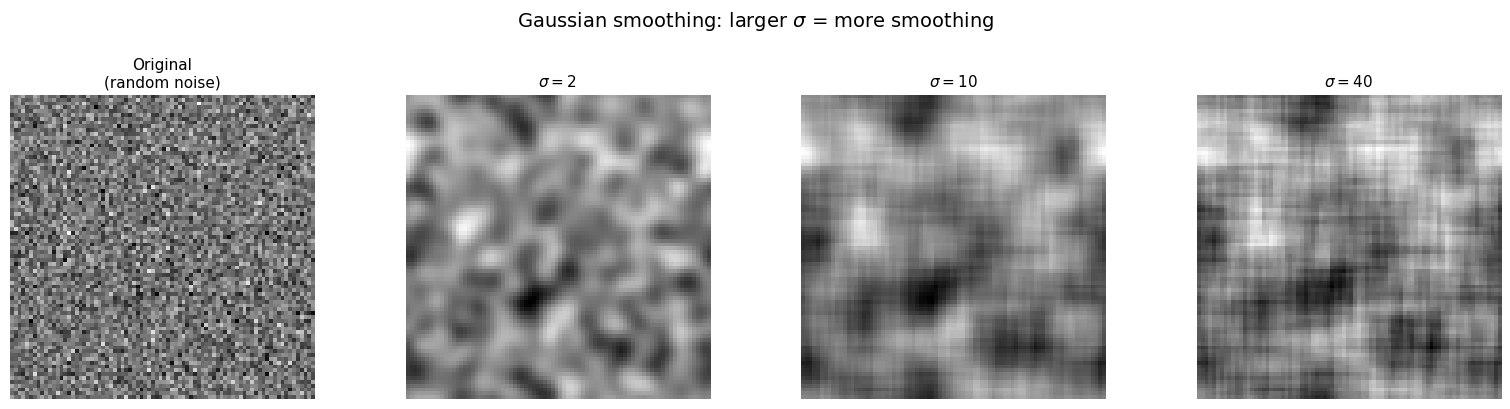

Sigma values tested: [2, 10, 40]


In [11]:
# Demonstrate the effect of sigma on smoothing
np.random.seed(42)
img_noise = np.random.randn(80, 80)

sigmas = [2, 10, 40]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img_noise, cmap='gray')
axes[0].set_title('Original\n(random noise)', fontsize=11)
axes[0].axis('off')

for ax, s in zip(axes[1:], sigmas):
    Y_g, X_g = np.meshgrid(np.linspace(-3, 3, 15), np.linspace(-3, 3, 15))
    K = np.exp(-(X_g**2 + Y_g**2) / s)
    K /= np.sum(K)

    smoothed = convolve2d(img_noise, K, mode='same', boundary='wrap')
    ax.imshow(smoothed, cmap='gray')
    ax.set_title(f'$\\sigma = {s}$', fontsize=11)
    ax.axis('off')

plt.suptitle('Gaussian smoothing: larger $\\sigma$ = more smoothing', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_sigma_effect.png', dpi=100, bbox_inches='tight')
plt.show()
print('Sigma values tested:', sigmas)

As $\sigma$ increases, the Gaussian kernel becomes wider (flatter), averaging over a larger neighbourhood. The effect progresses from light denoising ($\sigma = 2$) to aggressive blurring ($\sigma = 40$) that reveals only the coarsest structures.

In practice, the choice of $\sigma$ depends on the application:
- **Image denoising:** Small $\sigma$ to preserve detail
- **Background estimation:** Large $\sigma$ to capture broad trends
- **Scale-space analysis:** Multiple $\sigma$ values simultaneously, to detect features at different scales (used in SIFT and other keypoint detectors)

## 4. Chapter Summary

This chapter demonstrated three matrix applications, each building on the vector operations from Chapter 4:

**Covariance matrices** extend the bivariate dot product to all pairs of variables simultaneously. The elegant formula $\mathbf{C} = \frac{1}{n-1}\tilde{\mathbf{X}}^T\tilde{\mathbf{X}}$ produces a symmetric $p \times p$ matrix where each element is a pairwise covariance. Dividing by the product of standard deviations converts to the correlation matrix $\mathbf{R}$. The covariance matrix is the starting point for PCA (Chapter 15), factor analysis, and portfolio optimisation.

**Geometric transformations** use matrix-vector multiplication $\mathbf{T}\mathbf{p}$ to rotate, scale, and shear coordinates. Pure rotation matrices are orthogonal ($\mathbf{T}^T\mathbf{T} = \mathbf{I}$) and preserve lengths. The determinant of the transformation matrix gives the area/volume scale factor, and $\det = 0$ means a dimension is collapsed. The "Wobbly Circle" demonstrated how parameterised transformations create animations.

**Image filtering** extends 1D dot-product filtering to 2D using Hadamard-product-and-sum with a sliding 2D kernel. Gaussian kernels smooth images; Sobel kernels detect edges. The kernel's shape determines what feature is detected, and modern CNNs learn optimal kernels through gradient descent.

The unifying theme: **matrix operations are organised collections of the dot products and norms** from Chapters 2--4. The covariance matrix is a matrix of dot products. Convolution is a matrix of local dot products. Transformation is a matrix encoding a specific rotation/scaling applied via the dot product. Linear algebra becomes more powerful as we scale from vectors to matrices, but the foundations remain the same.